### Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, 
                            log_loss, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
# Create synthetic customer purchase data
X, y = make_classification(
    n_samples=1000,           # 1000 customers
    n_features=3,             # 3 features
    n_informative=3,          # All features useful
    n_redundant=0,
    n_classes=2,
    random_state=42
)

# Create dataframe for better viewing
feature_names = ['Age', 'Income', 'Visits']
df = pd.DataFrame(X, columns=feature_names)
df['Purchased'] = y

print("📊 Dataset created!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 customers:")
print(df.head())

print(f"\n📈 Target Distribution:")
print(df['Purchased'].value_counts())
print(f"0 = Did NOT purchase ({df['Purchased'].value_counts()[0]})")
print(f"1 = Purchased ({df['Purchased'].value_counts()[1]})")

📊 Dataset created!
Shape: (1000, 4)

First 5 customers:
        Age    Income    Visits  Purchased
0  0.521706  0.726857  2.504102          1
1 -1.019710 -0.749860 -0.713463          0
2 -1.892225 -1.032171  1.541761          0
3  0.625801 -0.866283 -0.350923          0
4  1.034612  1.641388  3.182540          1

📈 Target Distribution:
Purchased
0    501
1    499
Name: count, dtype: int64
0 = Did NOT purchase (501)
1 = Purchased (499)


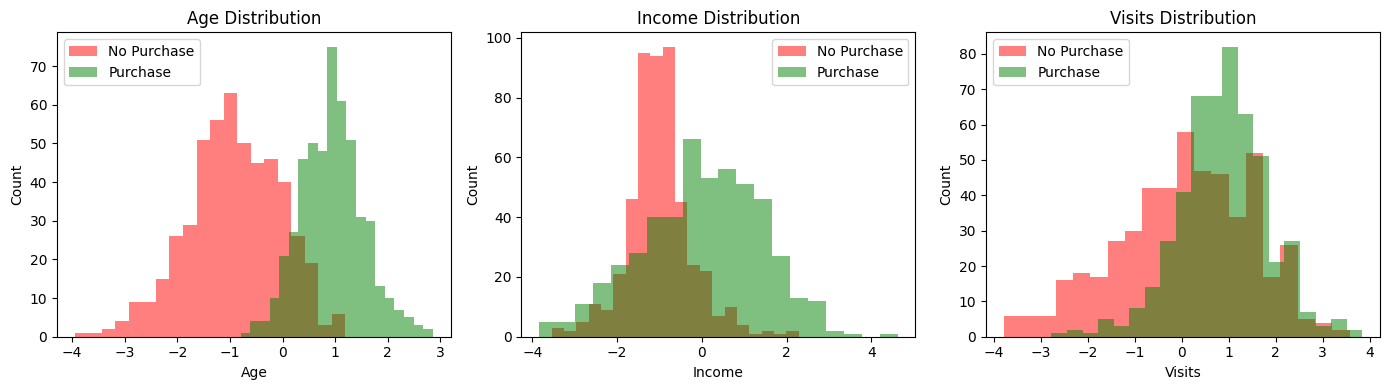

📌 Green = Purchased, Red = Did not purchase
If green and red are well separated → Feature is useful!


In [3]:
# Simple scatter plot to see patterns
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot each feature against target
for i, feature in enumerate(feature_names):
    ax = axes[i]
    # Separate by purchase status
    no_purchase = df[df['Purchased'] == 0][feature]
    yes_purchase = df[df['Purchased'] == 1][feature]
    
    # Histograms
    ax.hist(no_purchase, alpha=0.5, label='No Purchase', color='red', bins=20)
    ax.hist(yes_purchase, alpha=0.5, label='Purchase', color='green', bins=20)
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.set_title(f'{feature} Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

print("📌 Green = Purchased, Red = Did not purchase")
print("If green and red are well separated → Feature is useful!")

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions (probabilities)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of "Yes"
y_pred = model.predict(X_test)              # Binary prediction (0 or 1)

print("🤖 MODEL TRAINED!")
print("="*50)
print("Model Formula:")
print("z = ", end="")
for i, feat in enumerate(feature_names):
    coef = model.coef_[0][i]
    if coef > 0:
        print(f" + {coef:.3f}×{feat}", end="")
    else:
        print(f" {coef:.3f}×{feat}", end="")
print(f" + {model.intercept_[0]:.3f}")
print("\nThen: Probability = 1 / (1 + e^(-z))")
print("Decision: If Probability >= 0.5 → Purchase")

🤖 MODEL TRAINED!
Model Formula:
z =  + 3.403×Age + 0.713×Income + 0.336×Visits + 0.098

Then: Probability = 1 / (1 + e^(-z))
Decision: If Probability >= 0.5 → Purchase


In [6]:
# Calculate metrics
log_loss_score = log_loss(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("📊 MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Log-Loss: {log_loss_score:.4f}")
print(f"  (0=perfect, 0.693=random guessing, higher=worse)")
print(f"\nROC-AUC Score: {auc_score:.4f}")
print(f"  (0.5=random, 1.0=perfect, >0.8=good)")
print("\n" + "="*50)

# Classification Report
print("\n📋 CLASSIFICATION REPORT:")
print("="*50)
print(classification_report(y_test, y_pred, 
                          target_names=['No Purchase', 'Purchase']))

print("\n📖 Understanding the metrics:")
print("Precision = Of all 'Purchase' predictions, how many were correct?")
print("Recall    = Of all actual 'Purchases', how many did we catch?")
print("F1-Score  = Harmonic mean of Precision and Recall")

📊 MODEL PERFORMANCE METRICS
Log-Loss: 0.2293
  (0=perfect, 0.693=random guessing, higher=worse)

ROC-AUC Score: 0.9680
  (0.5=random, 1.0=perfect, >0.8=good)


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 No Purchase       0.92      0.91      0.91       110
    Purchase       0.89      0.90      0.90        90

    accuracy                           0.91       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.91      0.91      0.91       200


📖 Understanding the metrics:
Precision = Of all 'Purchase' predictions, how many were correct?
Recall    = Of all actual 'Purchases', how many did we catch?
F1-Score  = Harmonic mean of Precision and Recall


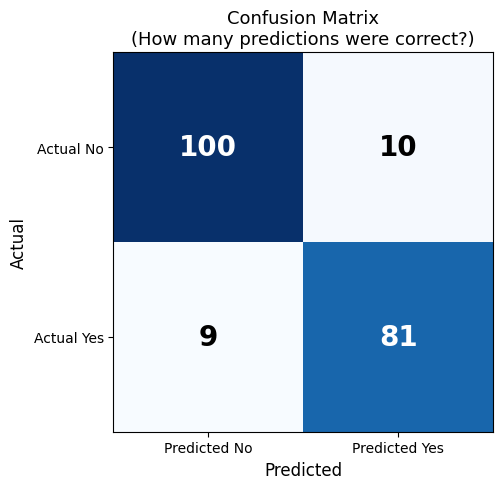


📌 INTERPRETATION:
✅ Correct Predictions: 181 (Diagonal)
❌ Wrong Predictions: 19 (Off-diagonal)

True Negatives (TN) = 100 (Correctly predicted NO)
True Positives (TP) = 81 (Correctly predicted YES)
False Positives (FP) = 10 (False alarms)
False Negatives (FN) = 9 (Missed opportunities)


In [7]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot simple confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

# Create colored grid
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')

# Add values
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j],
                      ha="center", va="center",
                      color="white" if cm[i, j] > cm.max()/2 else "black",
                      fontsize=20, fontweight='bold')

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted No', 'Predicted Yes'])
ax.set_yticklabels(['Actual No', 'Actual Yes'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix\n(How many predictions were correct?)', fontsize=13)

plt.tight_layout()
plt.show()

print("\n📌 INTERPRETATION:")
print(f"✅ Correct Predictions: {cm[0,0] + cm[1,1]} (Diagonal)")
print(f"❌ Wrong Predictions: {cm[0,1] + cm[1,0]} (Off-diagonal)")
print(f"\nTrue Negatives (TN) = {cm[0,0]} (Correctly predicted NO)")
print(f"True Positives (TP) = {cm[1,1]} (Correctly predicted YES)")
print(f"False Positives (FP) = {cm[0,1]} (False alarms)")
print(f"False Negatives (FN) = {cm[1,0]} (Missed opportunities)")